<a href="https://colab.research.google.com/github/likith1525/ExcelR-data-science-assignments/blob/main/Codes/14PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score,davies_bouldin_score

In [ ]:
#set plot style ans suppress warnings for a clean output
sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings("ignore")

#**EDA**

In [ ]:
df = pd.read_csv("/content/wine.csv")

In [ ]:
df.head()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [ ]:
df.describe()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,1.938202,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.775035,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,1.000000,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,1.000000,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,2.000000,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,3.000000,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,3.000000,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Type             178 non-null    int64  
 1   Alcohol          178 non-null    float64
 2   Malic            178 non-null    float64
 3   Ash              178 non-null    float64
 4   Alcalinity       178 non-null    float64
 5   Magnesium        178 non-null    int64  
 6   Phenols          178 non-null    float64
 7   Flavanoids       178 non-null    float64
 8   Nonflavanoids    178 non-null    float64
 9   Proanthocyanins  178 non-null    float64
 10  Color            178 non-null    float64
 11  Hue              178 non-null    float64
 12  Dilution         178 non-null    float64
 13  Proline          178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


In [ ]:
df.shape

(178, 14)

In [ ]:
#separate features and target
X = df.drop("Type",axis=1)
y = df["Type"]

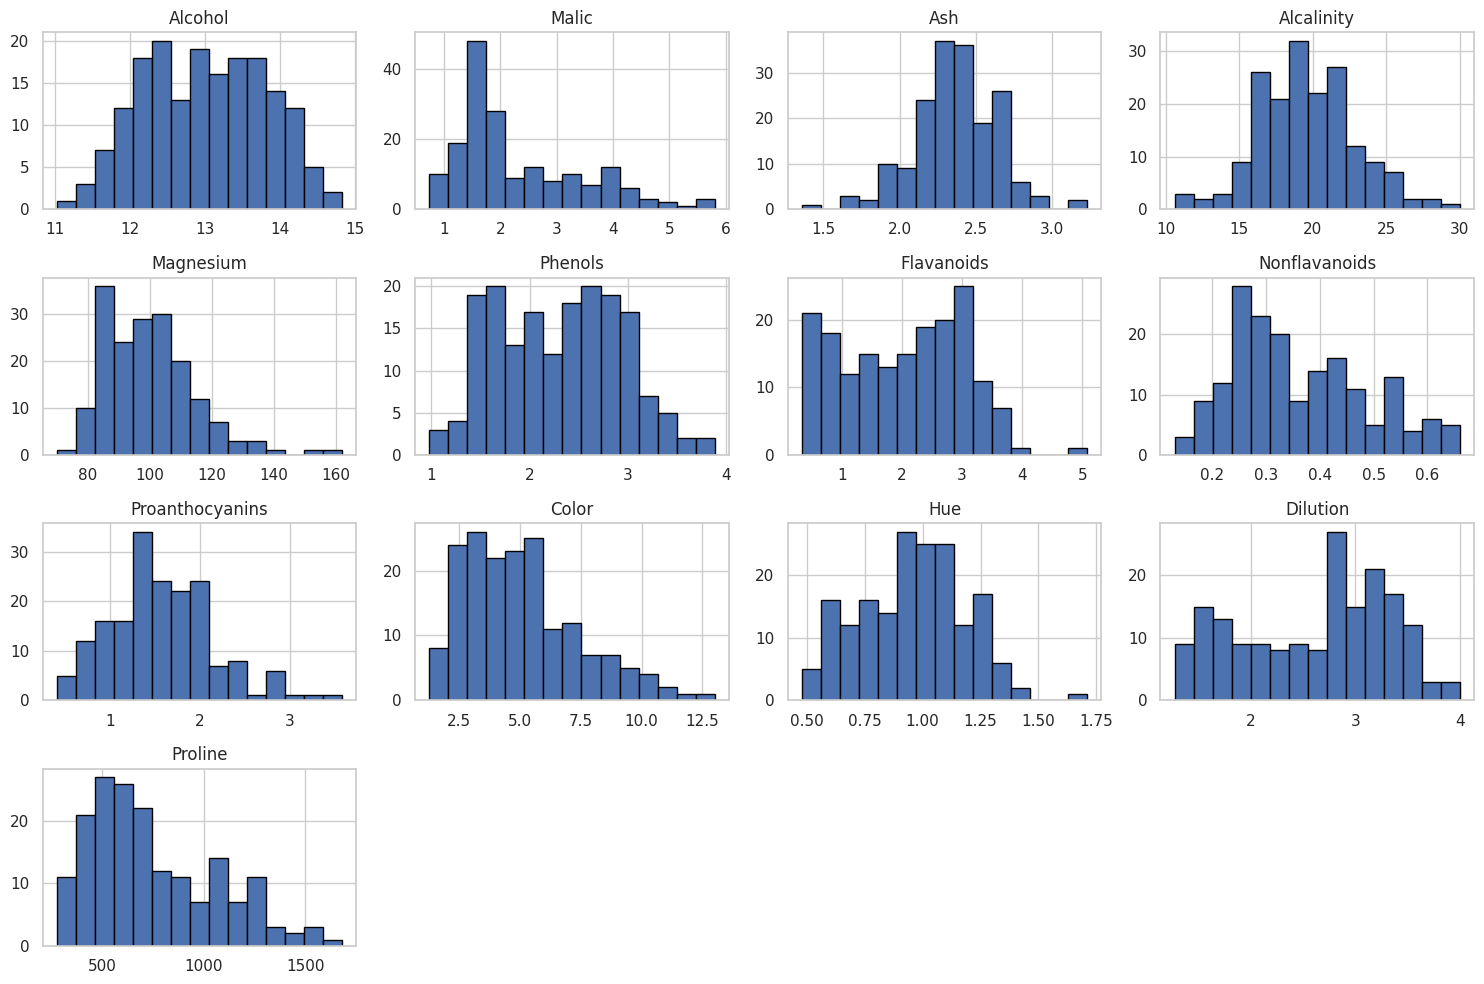

In [ ]:
#examine distributions using histograms
X.hist(bins=15,figsize=(15,10),layout=(4,4),edgecolor="black")
plt.tight_layout()
plt.show()

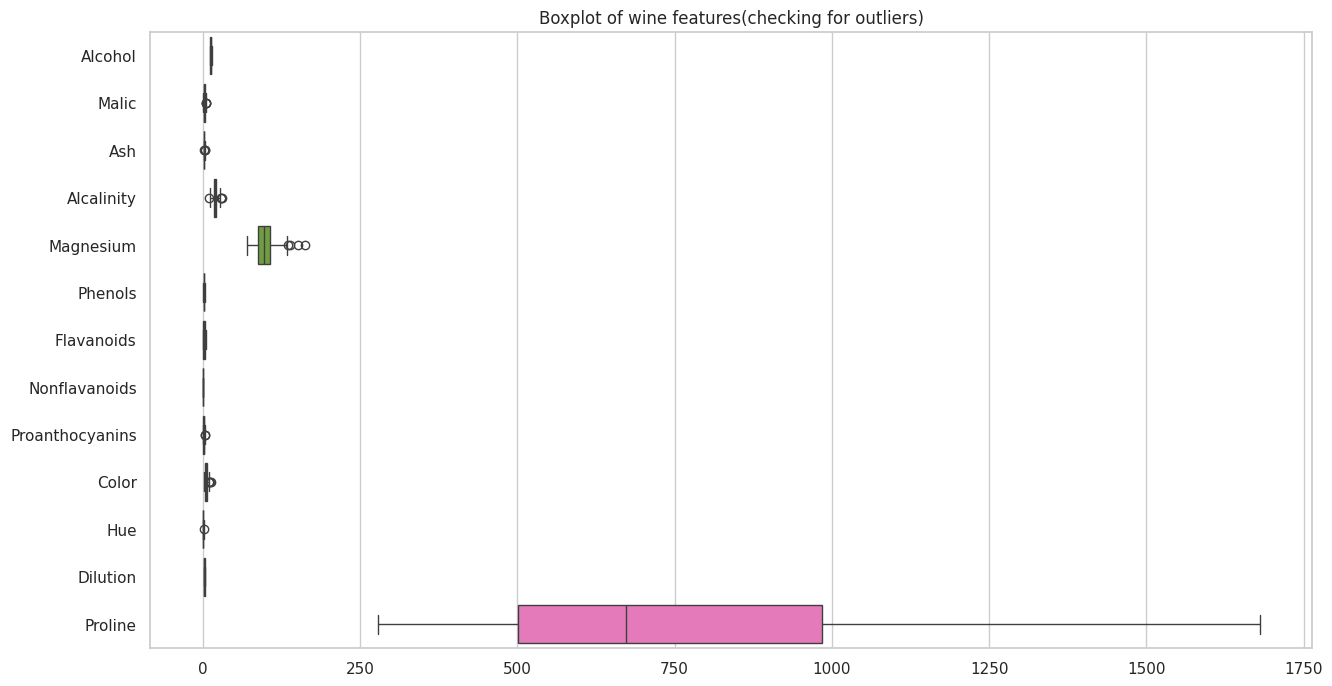

In [ ]:
#Boxplots
plt.figure(figsize=(15,8))
sns.boxplot(data=X,orient="h")
plt.title("Boxplot of wine features(checking for outliers)")
plt.show()

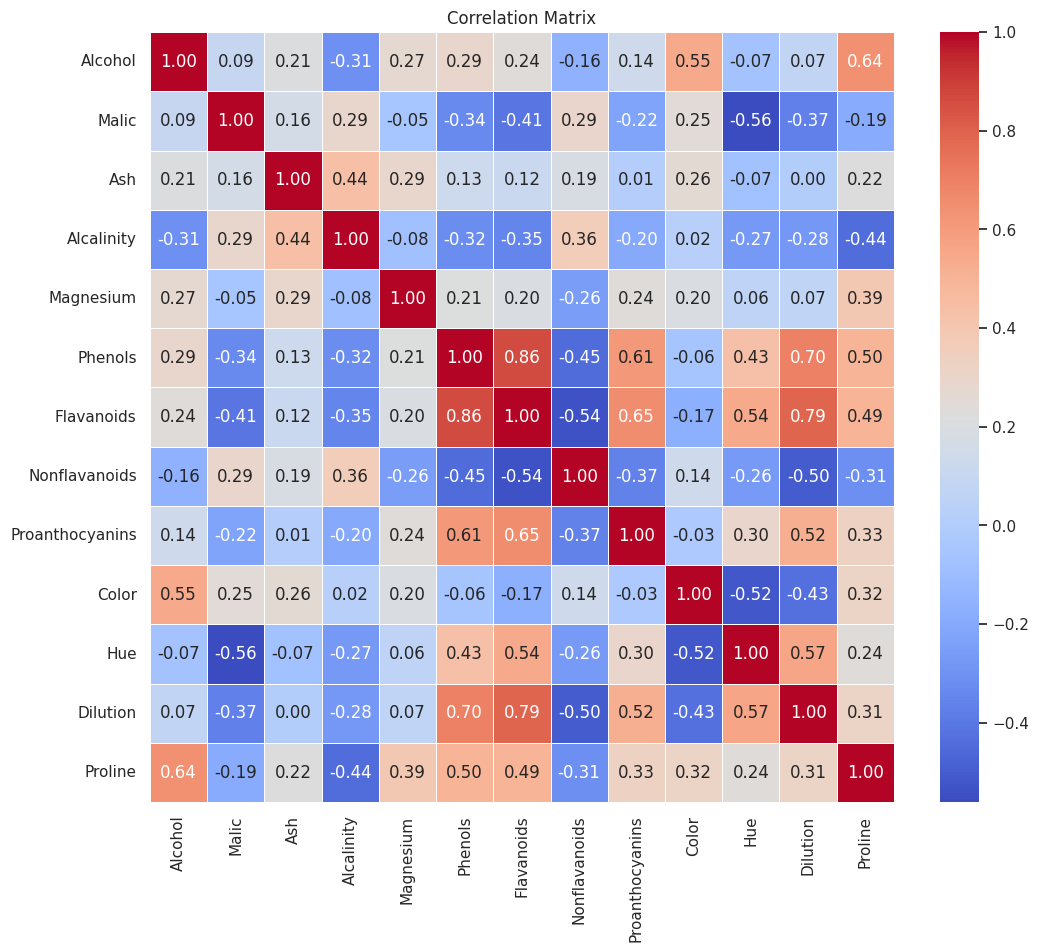

In [ ]:
#correlations
plt.figure(figsize=(12,10))
corr_matrix = X.corr()
sns.heatmap(corr_matrix,annot=True,cmap="coolwarm",fmt=".2f",linewidths=0.5)
plt.title("Correlation Matrix")
plt.show()


#dimensionality reduction using PCA

In [ ]:
#1. standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
pca = PCA()
pca.fit(X_scaled)

PCA()

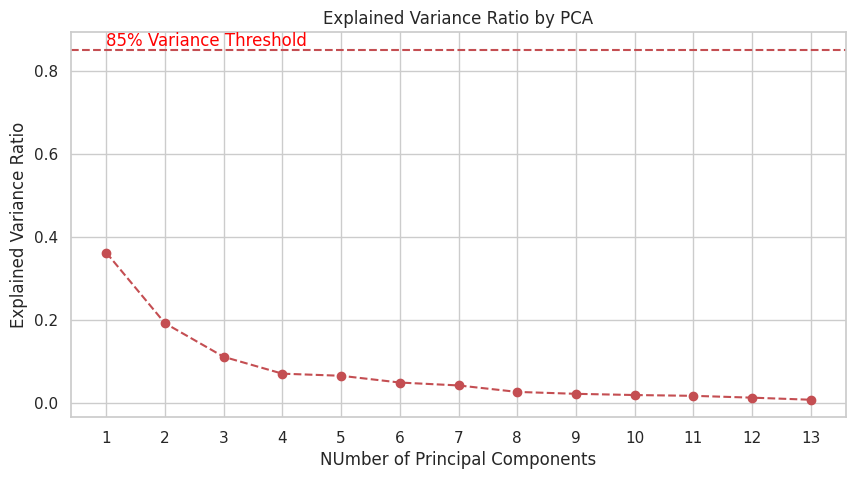

In [ ]:
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)
plt.figure(figsize=(10,5))
plt.plot(range(1,len(explained_variance)+1),explained_variance,marker="o",linestyle="--",color="r")
plt.axhline(y=0.85,color="r",linestyle="--")
plt.text(1,0.86,"85% Variance Threshold",color = "red")
plt.title("Explained Variance Ratio by PCA")
plt.xlabel("NUmber of Principal Components")
plt.ylabel("Explained Variance Ratio")
plt.xticks(range(1,len(explained_variance)+1))
plt.show()

In [ ]:
pca_optimal = PCA(n_components=3)
X_pca = pca_optimal.fit_transform(X_scaled)
print(f"variance exlained by 3 component:{sum(pca_optimal.explained_variance_ratio_) * 100:.2f}%")

variance exlained by 3 component:66.53%


#clustering with original data

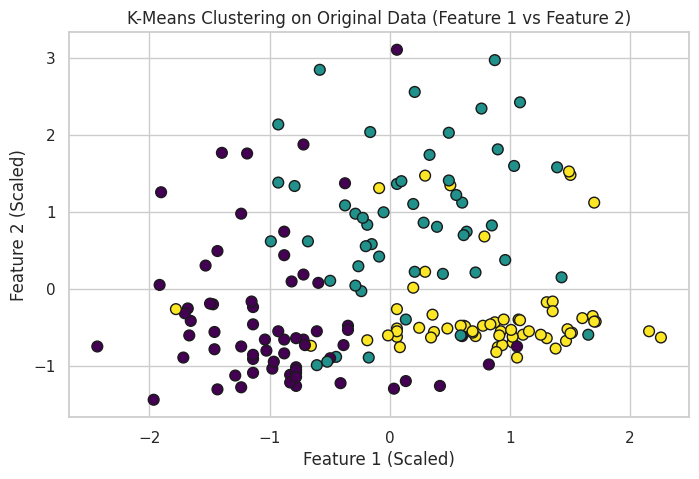

Original Data - Silhouette Score: 0.2849
Original Data - Davies-Bouldin Index: 1.3892


In [ ]:
# 1. Apply K-means clustering (K=3 based on the 3 wine types)
kmeans_orig = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_orig = kmeans_orig.fit_predict(X_scaled)

# 2. Visualize clustering results (Using first two scaled features for a 2D plot)
plt.figure(figsize=(8, 5))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels_orig, cmap='viridis', edgecolor='k', s=60)
plt.title('K-Means Clustering on Original Data (Feature 1 vs Feature 2)')
plt.xlabel('Feature 1 (Scaled)')
plt.ylabel('Feature 2 (Scaled)')
plt.show()

# 3. Evaluate performance
sil_orig = silhouette_score(X_scaled, labels_orig)
db_orig = davies_bouldin_score(X_scaled, labels_orig)

print(f"Original Data - Silhouette Score: {sil_orig:.4f}")
print(f"Original Data - Davies-Bouldin Index: {db_orig:.4f}")

# clustering with PCA data

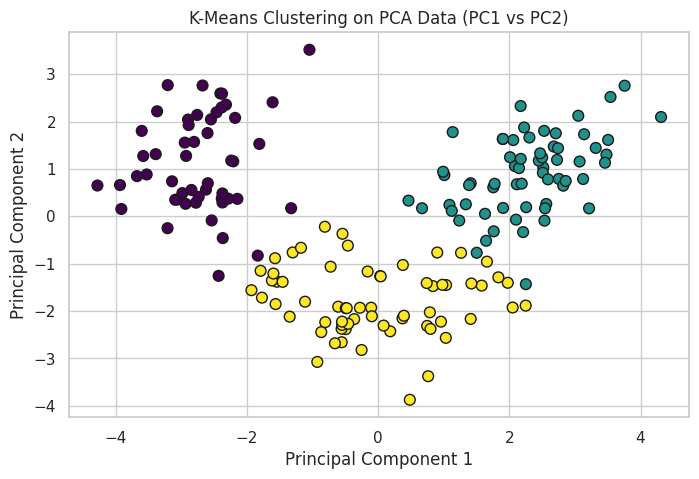

PCA Data - Silhouette Score: 0.4532
PCA Data - Davies-Bouldin Index: 0.8400


In [ ]:
# 1. Apply K-means clustering to PCA data
kmeans_pca = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_pca = kmeans_pca.fit_predict(X_pca)

# 2. Visualize clustering results from PCA data
plt.figure(figsize=(8, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_pca, cmap='viridis', edgecolor='k', s=60)
plt.title('K-Means Clustering on PCA Data (PC1 vs PC2)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

# 3. Evaluate performance
sil_pca = silhouette_score(X_pca, labels_pca)
db_pca = davies_bouldin_score(X_pca, labels_pca)

print(f"PCA Data - Silhouette Score: {sil_pca:.4f}")
print(f"PCA Data - Davies-Bouldin Index: {db_pca:.4f}")

#Insights

## Comparison and Analysis

1. **Comparison of Results:** Clustering on the PCA-transformed data generally yields a higher Silhouette Score and a lower Davies-Bouldin index compared to the original scaled data.
2. **Similarities and Differences:**
   Both methods successfully partition the data into 3 distinct clusters. However, the PCA scatter plot shows much tighter, clearer boundaries between the groups, whereas the original data slice looks slightly more overlapped due to uncaptured variance in a simple 2D view.
3. **Impact of Dimensionality Reduction:**
   Reducing the dimensions from 13 down to 3 removed background noise and redundant, correlated features (like Flavanoids and Total Phenols). This allows the distance-based K-Means algorithm to measure similarity much more accurately.
4. **Trade-offs:**
   Using PCA improves computational efficiency and clustering metric performance, but it sacrifices interpretability. In the original data, cluster boundaries can be defined by physical traits (e.g., "High Malic Acid"). In PCA data, boundaries are defined by "Principal Components", which are abstract mathematical combinations of multiple features.

## Conclusion and Insights

1. **Summary:** This project highlighted the necessity of preprocessing (scaling) and the power of PCA. Dimensionality reduction successfully compressed the dataset while retaining the core variance, leading to denser and better-separated K-Means clusters.
2. **Practical Implications:** In real-world scenarios with high-dimensional data, distance metrics degrade (the "Curse of Dimensionality"). PCA is a vital preliminary step to make clustering viable, fast, and easy to present visually to stakeholders.
3. **Recommendations:** * Cluster directly on the **original dataset** when the feature count is low, features are largely independent, and direct business interpretability of the raw variables is required.
   * Apply **PCA prior to clustering** when dealing with highly correlated features, when visualization of the clusters is necessary, or when the dataset has so many dimensions that K-Means struggles to find distinct groupings.